In [ ]:
import sys
sys.path.append('..')

from src.flow_matching.distributions import Gaussian, CheckerboardSampleable
from src.flow_matching.probability_path import LinearConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPVectorField
from src.helpers import record_every
from src.flow_matching.plotting import hist2d_samples
from src.flow_matching.helpers import choose_device

from matplotlib import pyplot as plt
import torch

device = choose_device()

# Example from MIT Lab two

Modified example from the MIT course where isotropic Gaussian is transformed into an arbitrary distribution via a linear conditional probability path, comparing the ground-truth path and the path resulting from a learned vector field. 

In [2]:
# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Gaussian.isotropic(dim=2, std=1.0),
    p_data = CheckerboardSampleable(device, grid_size=4)
).to(device)

# Construct learnable vector field
vector_field = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, vector_field)
losses = trainer.train(num_epochs=10000, device=device, lr=1e-3, batch_size=2000, save_checkpoint=False)

Training model with size: 0.049 MiB


Epoch 9999, loss: 8.855, lr: 3.11e-05: 100%|██████████| 10000/10000 [03:10<00:00, 52.37it/s]


100%|██████████| 99/99 [00:00<00:00, 1452.29it/s]


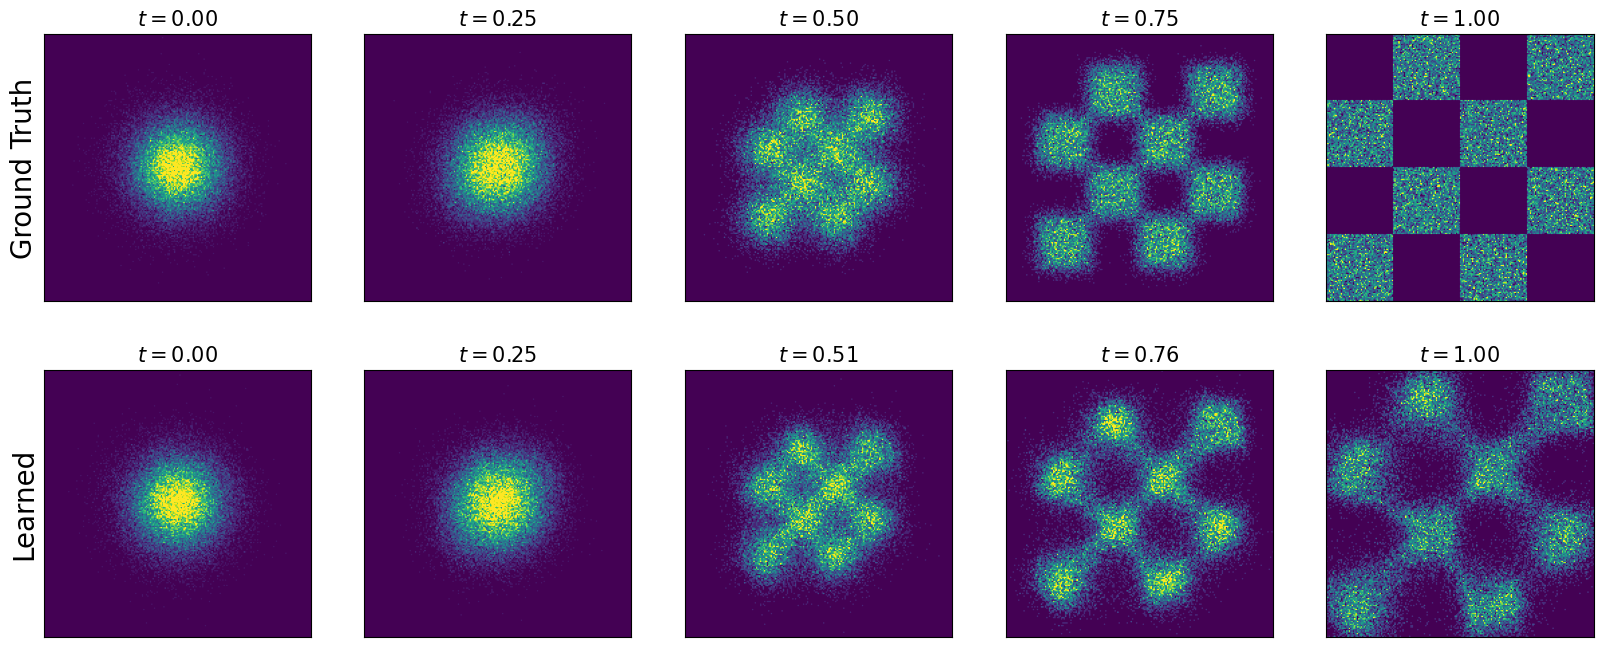

In [16]:
num_marginals = 5    # number of snapshots to plot
num_samples = 50000  # number of samples per snapshot 

plt.figure(figsize=(20,8))

# -------------------------------------------- #
#        Plotting Ground-Truth Marginals       #
# -------------------------------------------- #

ts = torch.linspace(0.0, 1.0, num_marginals).to(device)

for idx, t in enumerate(ts):

    tt = t.view(1,1).expand(num_samples, 1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts.cpu(), range=[[-5, 5], [-5, 5]])

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={t.item():.2f}$', fontsize=15)

    plt.ylabel("Ground Truth", fontsize=20) if idx == 0 else None

# --------------------------------------------  #
#  Plotting Marginals of Learned Vector Field   #
# -------------------------------------------   #

# initialize ODE solver
simulator = EulerODESolver(vector_field)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ODE from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# save only num_marginal snapshots of the trajectory
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

plot_idx = idx + 1

# plot the snapshots
for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]

    plt.subplot(2, num_marginals, plot_idx + idx + 1)
    hist2d_samples(xx.cpu(), range=[[-5, 5], [-5, 5]])

    tt = ts[record_every_idxs[idx]]

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={tt.item():.2f}$', fontsize=15)
    plt.ylabel("Learned", fontsize=20) if idx == 0 else None

plt.show()
